In [3]:
import numpy as np
from glob import glob
import os
import gc
from pathlib import Path
import yaml

from matplotlib import pyplot as plt
from cycler import cycler
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.backends.backend_pdf import PdfPages
plt.style.use('clarke-default')

from scipy.optimize import curve_fit
import scipy.signal as sig
from scipy import stats

from importlib import reload

import sys
sys.path.insert(0, '../nano_utils/')
import data_processing as dp

### Look through the drive/data directory and print folder structure
This cell will look through the specified directory and populate a dictionary of the datasets it contains.

In [ ]:
# drive_path = '/Users/clarke/Data'
drive_path = '/Volumes/LaCie/'

sphere_date = '20260215'
# sphere_date = '20251212'
sphere_diam = 100.
# sphere_diam = 166.

base_path = f'{drive_path}/gas_collisions/pulse_calibration/sphere_{sphere_date}/'

if not os.path.exists(drive_path):
    print('Error: check that the external drive is plugged in!')

folders = glob(base_path + '*')

datasets = {}

for folder in folders:
    print(folder.split(base_path)[-1])
    all_items = glob(folder + '/*.hdf5')
    subfolders = np.unique(['_'.join(s.split('_')[:-1]) for s in all_items])
    sub_datasets = []
    for subfolder in subfolders:
        sub_datasets.append(subfolder.split(base_path)[-1].split('/')[-1])
        print('\t' + subfolder.split(base_path)[-1].split('/')[-1])
    datasets[folder.split(base_path)[-1]] = sub_datasets

20260216_p6e_6e-8mbar_d137khz_0
	20260216_dfg_p6e_200ns_10.0v
	20260216_dfg_p6e_200ns_12.5v
	20260216_dfg_p6e_200ns_15.0v
	20260216_dfg_p6e_200ns_17.5v
	20260216_dfg_p6e_200ns_2.5v
	20260216_dfg_p6e_200ns_20.0v
	20260216_dfg_p6e_200ns_5.0v
	20260216_dfg_p6e_200ns_7.5v
20260216_electric_calibration_6e-8mbar_0
	20260216_d_p6e_117khz_0.5vpp_lensholder1
	20260216_d_p6e_117khz_1vpp_lensholder1
20260216_electric_calibration_6e-8mbar_1
	20260216_d_p6e_117khz_1vpp
	20260216_d_p6e_117khz_2vpp_lensholder2
20260216_p6e_6e-8mbar_d137khz_gas_trial
	20260216_dfg_p6e_200ns_20.0v
20260219_p6e_4e-8mbar_d137khz_1_afterxe
	20260219_dfg_p6e_200ns_10v
	20260219_dfg_p6e_200ns_12.5v
	20260219_dfg_p6e_200ns_15v
	20260219_dfg_p6e_200ns_17.5v
	20260219_dfg_p6e_200ns_2.5v
	20260219_dfg_p6e_200ns_20v
	20260219_dfg_p6e_200ns_5v
	20260219_dfg_p6e_200ns_7.5v
20260219_p6e_4e-8mbar_d137khz_2_afterkr
	20260219_dfg_p6e_200ns_10v
	20260219_dfg_p6e_200ns_12.5v
	20260219_dfg_p6e_200ns_15v
	20260219_dfg_p6e_200ns_17.5v
	202

### Specify impulse and analysis parameters
Set relevant analysis parameters here. They will be added to a config dictionary which is used during the file loading step. The same config dictionary will then be updated with the calibration parameters and saved to a YAML file for later use with the search data.

In [5]:
pulse_amps_1e = np.asarray([12, 34, 57, 80, 103, 127, 150, 174]) # impulses applied to the particle in eV/c
pulse_amps_V = np.arange(2.5, 21, 2.5) # pulse amplitudes applied to lens holder 1 in V

search_window = 5e-5 # time window for impulse search
fit_window = 1e-1 # time window for resonance fits
f_cutoff_high = 1e5 # upper cutoff frequency for the bandpass filter
f_cutoff_low = 2.5e4 # lower cutoff frequency for the bandpass filter
f_cutoff = [f_cutoff_low, f_cutoff_high]

config = {
    'fit_window': fit_window,
    'search_window': search_window,
    'meters_per_volt': None,
    'f_cutoff': f_cutoff,
    'apply_notch': True, # notch filter the data
    'calibrate': True, # automatically extract calibration factor from driven monitoring tone
    'd_sphere_nm': sphere_diam, # sphere diameter in nanometers
    'fixed_imprecision': False # use fixed imprecision noise level in optimal filtering (if False, noise is computed dynamically file-by-file)
}

### Load and process the data
`dataset_ind` should be chosen based on the order in which the datasets are printed above. All files at all different voltages from the specified dataset will be loaded in the loop in the cell below. The `plot` flag can be set to `True` to produce a standard set of diagnostic plots (note that this slows down the code significantly). The file with the lowest-amplitude impulses (usually 2.5 V) is processed twice: once using the true impulse delivery times, and once using shifted times to create a noise-only dataset.

In [6]:
reload(dp)

# choose which dataset to look at
dataset_ind = -1
dataset = list(datasets.keys())[dataset_ind]

# get the list of impulse amplitudes in that dataset
amp_list = np.argsort([float(d.split('v')[0].split('_')[-1]) for d in datasets[dataset]])
amp_list = np.concat(([amp_list[0]], amp_list))

pulse_amps_keV = []
impulses = []
resonance_params = []
fit_success = []
cal_facs = []
pulses = []
recon_inds = []
timestamps = []
pulse_times = []
meters_per_volt = []
impulse_rms = []

# number of files to look at for each amplitude
max_files = 10

# when plotting, only look at one file
plot = False
if plot:
    max_files = 1

# loop through all four files in that dataset in the correct order
for i, file_ind in enumerate(amp_list):
    if i == 0 and plot:
        continue
    filename = datasets[list(datasets.keys())[dataset_ind]][file_ind]
    plot_path = 'figures/' + base_path.split(drive_path)[-1] + dataset + '/' + filename \
                if plot else None
    nd = dp.NanoDataset(base_path + dataset + '/' + filename, plot_path, verbose=True, max_files=max_files, ds_factor=10, config=config)
    nd.load_calibration_data(global_params=False, pulse_amps_1e=pulse_amps_1e, pulse_amps_V=pulse_amps_V, noise=i==0)
    impulses.append(nd.impulses.copy())
    pulse_amps_keV.append([nd.pulse_amp_keV.copy(), 0][i==0])
    resonance_params.append(nd.resonance_params.copy())
    fit_success.append(nd.fit_success.copy())
    cal_facs.append(nd.cal_facs.copy())
    pulses.append(nd.pulses.copy())
    recon_inds.append(nd.recon_impulse_inds.copy())
    pulse_times.append(nd.pulse_times.copy())
    timestamps.append(nd.timestamps.copy())
    meters_per_volt.append(nd.meters_per_volt.copy())
    impulse_rms.append(nd.impulse_rms.copy())

    if i == 0:
        freqs = np.copy(nd.freqs)
    del nd
    
    if i > 0 and plot:
        break

if plot_path:
    plot_path = '_'.join(plot_path.split('_')[:-1])

min_len = min([len(i) for i in impulses])
pulse_amps_keV = np.array(pulse_amps_keV)
impulses = np.array([i[:min_len] for i in impulses])
pulses = np.array([i[:min_len] for i in pulses])
recon_inds = np.array([i[:min_len] for i in recon_inds])
resonance_params = np.array([i[:min_len] for i in resonance_params])
fit_success = np.array([i[:min_len] for i in fit_success])
cal_facs = np.array([i[:min_len] for i in cal_facs])
pulse_times = np.array([i[:min_len] for i in pulse_times])
timestamps = np.array([i[:min_len] for i in timestamps])
meters_per_volt = np.mean(meters_per_volt)
impulse_rms = np.array([i[:min_len] for i in impulse_rms])

Loading files starting with
/Volumes/LaCie//gas_collisions/pulse_calibration/sphere_20260215/20260219_p6e_4e-8mbar_d137khz_0/20260219_dfg_p6e_200ns_2.5v
  Loading file 1...
  Calibrating volts to meters...
    Mass of the nanosphere: 		1.388e-18 kg
    Number of charges on the sphere: 	6
    Electric field per volt applied: 	79.0 V/m
    Trap resonant frequency: 		47.1 kHz
    Drive signal from demodulation: 	0.474 V
    Applied force from demodulation: 	3.603e-17 N
    Sensor response from demodulation: 	1.472e-04 V
    Susceptibility at 137.0 kHz drive: 	1.103e+06 m/V
    Nanosphere response amplitude: 	3.973e-11 m
    Position calibration factor: 	2.707e-07 m/V
    -> Computing impulse for kick at t=0.01362 seconds...
    -> Computing impulse for kick at t=0.16362 seconds...
    -> Computing impulse for kick at t=0.31362 seconds...
    -> Computing impulse for kick at t=0.46362 seconds...
    -> Computing impulse for kick at t=0.61362 seconds...
    -> Computing impulse for kick at 

### Mask the data based on noise, fit convergence, and detection stability
Cuts can be applied based on RMS of the deconvolved waveforms (i.e. waveforms after optimal filter has been applied), fit convergence (not really necessary anymore as fitting is basically always stable), and detection stability. The detection stability is currently based on PSD in the frequency bin which contains the monitoring tone. Since the search window is so short, the frequency bin is huge and therefore the result can't really be interpreted in terms of the calibration factor. For now, it's more like a crude method of drop-out detection. To do: separate tracking of the calibration factor from drop-out detection so corrections/cuts can be applied based on both independently.

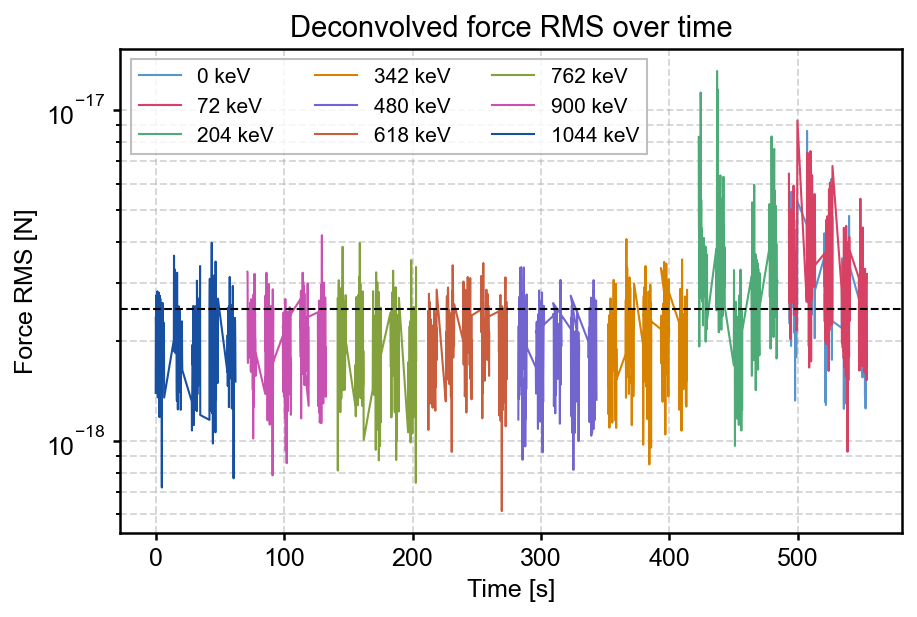

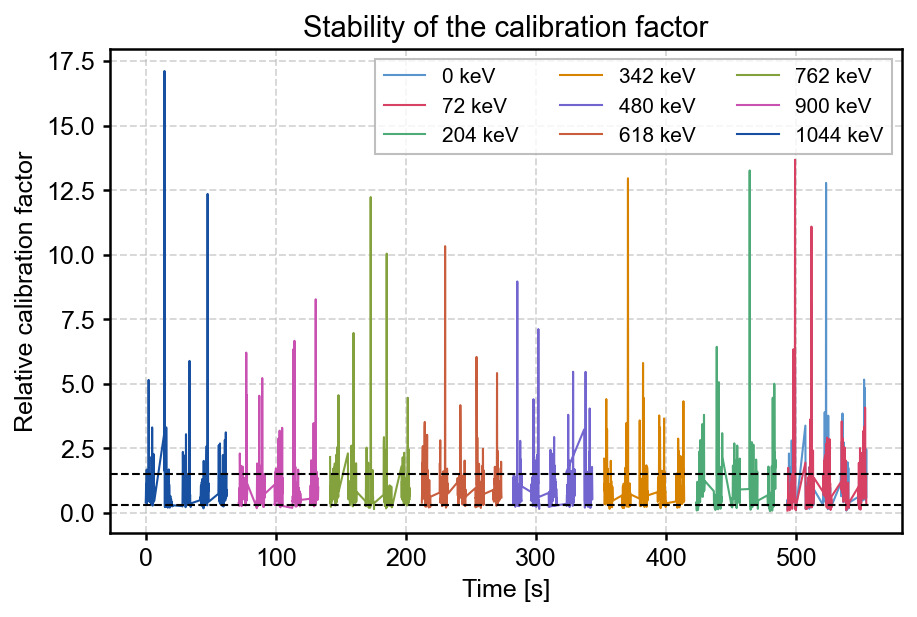

In [7]:
rms_cut = 2.5e-18 # cut on RMS noise in Newtons
rms_mask = impulse_rms < rms_cut

det_cuts = np.mean(cal_facs) + np.array((-0.03, 0.03))
det_cuts = np.array((0.3, 1.5))
det_mask = (cal_facs > det_cuts[0]) & (cal_facs < det_cuts[1])

# create a mask that includes the noise and the fit convergence
mask = rms_mask & fit_success & det_mask

n_repeats = (pulse_times.shape[1] + timestamps.shape[1] - 1) // timestamps.shape[1]
pulse_timestamps = pulse_times + np.repeat(timestamps, n_repeats, axis=1)[:, :pulse_times.shape[1]]
pulse_timestamps -= np.amin(pulse_timestamps)

fig, ax = plt.subplots(figsize=(6, 4), layout='constrained')

for i in range(impulse_rms.shape[0]):
    ax.plot(pulse_timestamps[i], np.abs(impulse_rms[i]), label='{:.0f} keV'.format(pulse_amps_keV[i]))

ax.set_xlabel('Time [s]')
ax.set_ylabel('Force RMS [N]')
ax.set_yscale('log')
ax.axhline(rms_cut, ls='--', color='k')
ax.legend(ncol=3, fontsize=10)
ax.grid(which='both')
ax.set_title('Deconvolved force RMS over time')
if plot_path:
    fig.savefig(plot_path + '_rms.pdf')

fig, ax = plt.subplots(figsize=(6, 4), layout='constrained')

for i in range(cal_facs.shape[0]):
    ax.plot(pulse_timestamps[i], cal_facs[i], label='{:.0f} keV'.format(pulse_amps_keV[i]))

ax.set_xlabel('Time [s]')
ax.set_ylabel('Relative calibration factor')
ax.axhline(det_cuts[0], ls='--', color='k')
ax.axhline(det_cuts[1], ls='--', color='k')
ax.legend(ncol=3, fontsize=10)
ax.grid(which='both')
ax.set_title('Stability of the calibration factor')
# ax.set_yscale('log')
if plot_path:
    fig.savefig(plot_path + '_det_stab.pdf')

### Monitor drifts in the resonance over time
The resonance parameters are taken from the susceptibility fits in each window of length `fit_window`. As $\gamma$ can't be determined accurately in such a short time window, it is extracted from the Voigt profile fit and treated as constant for a given file.

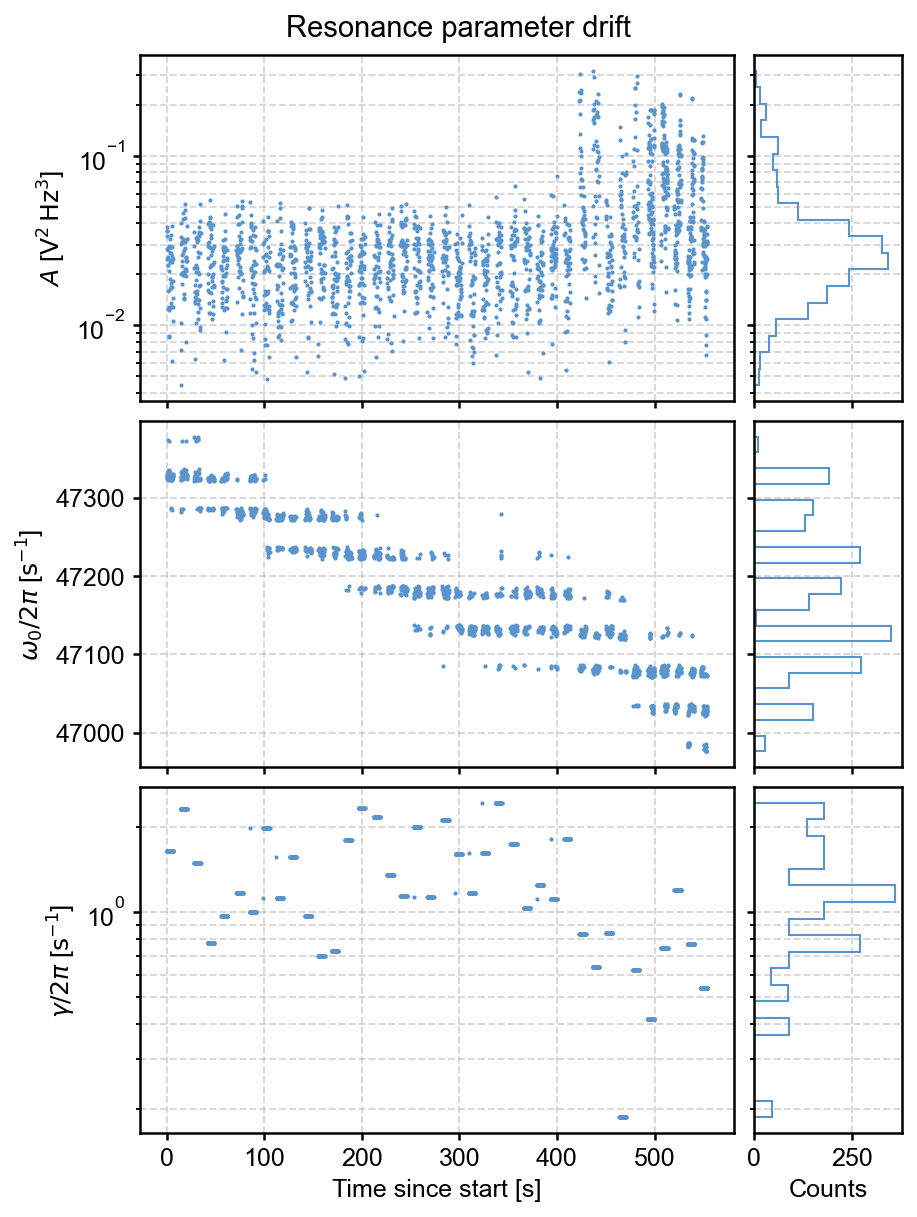

In [8]:
res_evol = np.array([resonance_params[...,i].flatten() for i in range(3)])
res_times = pulse_timestamps.flatten()

fig, ax = plt.subplots(3, 2, figsize=(6, 8), sharex='col', sharey='row', width_ratios=[4, 1], layout='constrained')
ax[0,0].semilogy(res_times, res_evol[0], marker='.', ms=2, ls='none')
ax[0,1].hist(res_evol[0], bins=np.logspace(np.log10(np.amin(res_evol[0])), \
             np.log10(np.amax(res_evol[0])), 20), histtype='step', orientation='horizontal')
ax[1,0].plot(res_times, res_evol[1]/2/np.pi, marker='.', ms=2, ls='none')
ax[1,1].hist(res_evol[1]/2/np.pi, bins=20, histtype='step', orientation='horizontal')
ax[2,0].semilogy(res_times, res_evol[2]/2/np.pi, marker='.', ms=2, ls='none')
ax[2,1].hist(res_evol[2]/2/np.pi, bins=np.logspace(np.log10(np.amin(res_evol[2]/2/np.pi)), \
             np.log10(np.amax(res_evol[2]/2/np.pi)), 20), \
             histtype='step', orientation='horizontal')
ax[0,0].set_ylabel(r'$A$ [$\mathrm{V^2\,Hz^3}$]')
ax[1,0].set_ylabel(r'$\omega_0/2\pi$ [$\mathrm{s}^{-1}$]')
ax[2,0].set_ylabel(r'$\gamma/2\pi$ [$\mathrm{s}^{-1}$]')
ax[2,0].set_xlabel('Time since start [s]')
ax[2,1].set_xlabel('Counts')
[ax[i, j].grid(which='both') for i in range(3) for j in range(2)]
# ax[0, 0].set_xlim([0, 15])
fig.suptitle('Resonance parameter drift')
if plot_path:
    fig.savefig(plot_path + '_res_evol.pdf')

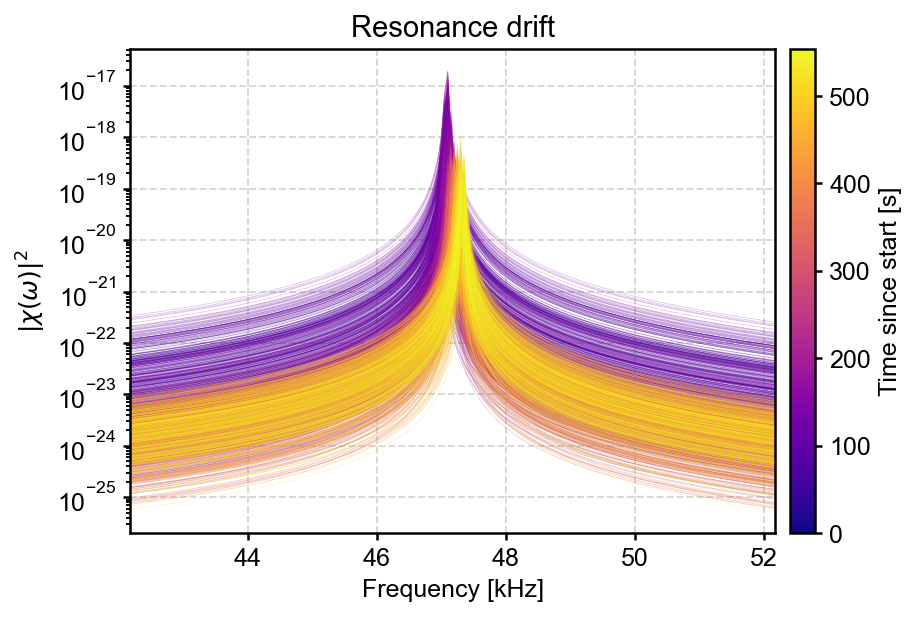

In [9]:
fig, ax = plt.subplots(figsize=(6, 4), layout='constrained')

freq_range = np.mean(res_evol[1])/2/np.pi/1e3 + np.array((-5, 5))

omegas = 2*np.pi*1e3*np.linspace(np.amin(freq_range), np.amax(freq_range), 200)
colors = [plt.get_cmap('plasma', res_evol.shape[1])(i) for i in range(res_evol.shape[1])]

for i, params in enumerate(res_evol.T):
    ax.plot(1e-3*omegas/2/np.pi, dp.abs_susc2(omegas, *params), alpha=0.3, lw=0.3, color=colors[i])

ax.set_yscale('log')
ax.set_xlabel('Frequency [kHz]')
ax.set_xlim(freq_range)
ax.set_ylabel(r'$|\chi(\omega)|^2$')
ax.set_title('Resonance drift')
ax.grid()
fig.colorbar(ScalarMappable(norm=Normalize(0, np.amax(res_times)), cmap='plasma'), ax=ax, label='Time since start [s]', pad=0.02)
if plot_path:
    fig.savefig(plot_path + '_res_drift.pdf')

### Look at the average waveform for each impulse magnitude

Here, we use the true impulse time to reconstruct the waveforms rather than the reconstructed impulse time.

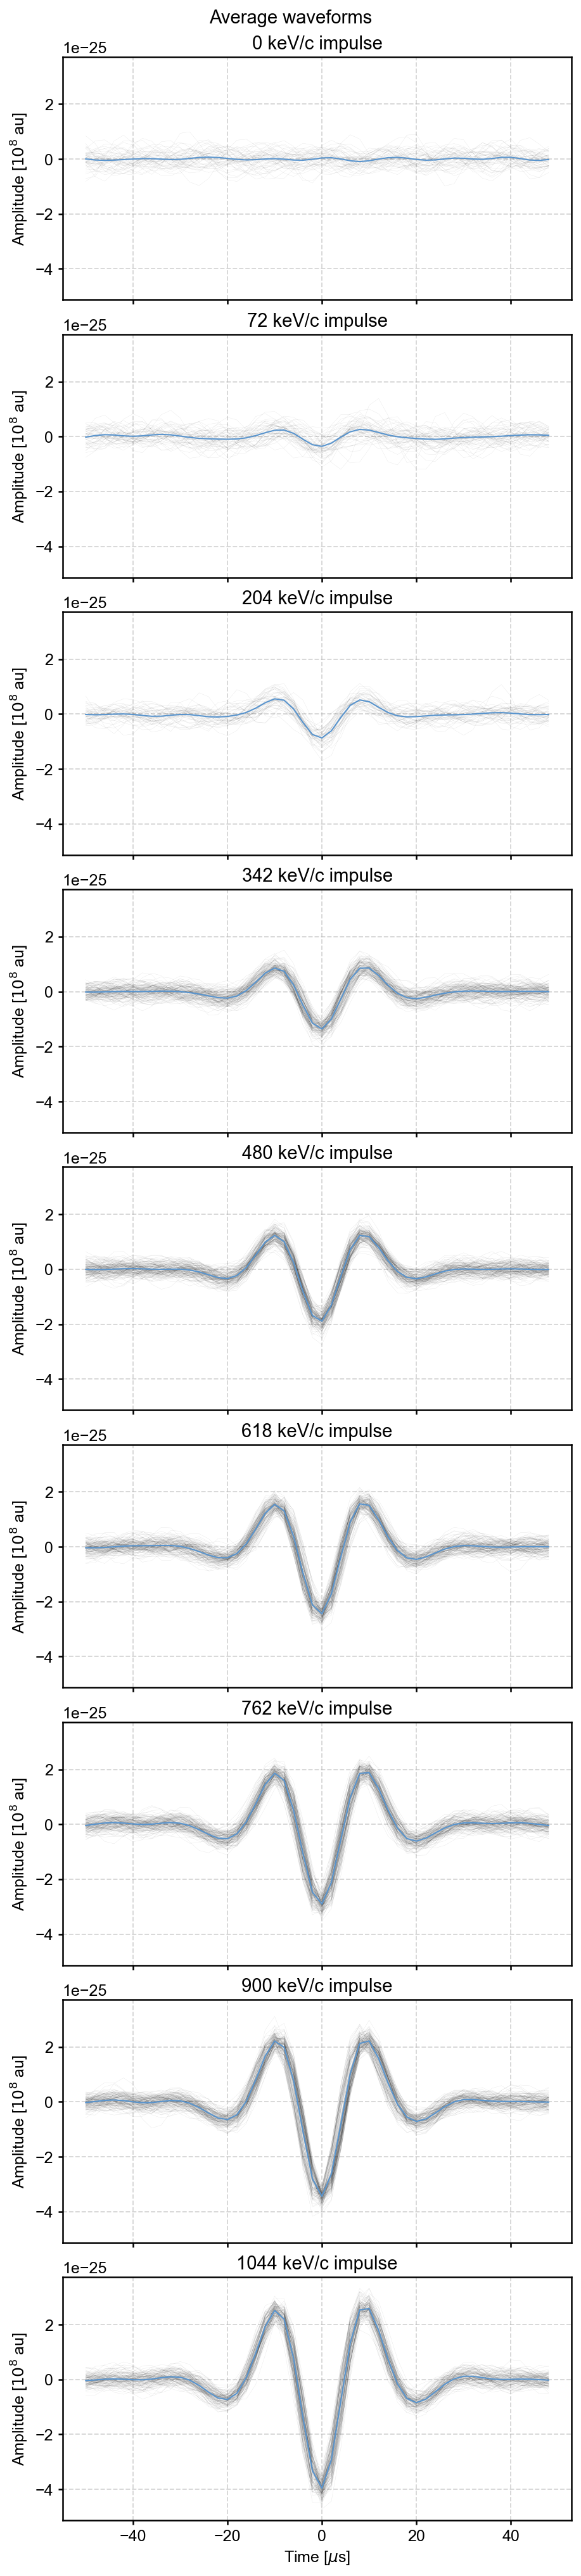

In [10]:
# build a time array
half_window = 25
peak_ind = np.argmax(np.abs(np.mean(pulses[-1], axis=0)))
times = np.arange(0, pulses.shape[-1]/2./freqs[-1], 1./2./freqs[-1])
times -= times[peak_ind]
time_slice = times[..., peak_ind - half_window:peak_ind + half_window]

# get the cropped waveforms centered around the true impulse time
pulses_true_imp = np.copy(pulses[..., peak_ind - half_window:peak_ind + half_window])
pulses_true_imp[~mask] = np.nan
mean_pulses_true_imp = np.nanmean(pulses_true_imp, axis=1)

# get the cropped waveforms centered around the reconstructed impulse time
# offsets = np.arange(2*half_window) - half_window
# time_inds = recon_inds[..., None] + offsets
# pulses_recon_imp = np.take_along_axis(pulses, time_inds, axis=2)
# mean_pulses_recon_imp = np.mean(pulses_recon_imp, axis=1)

fig, ax = plt.subplots(mean_pulses_true_imp.shape[0], figsize=(6, 3*mean_pulses_true_imp.shape[0]), \
                       sharex=True, sharey=True, layout='constrained')
for i in range(mean_pulses_true_imp.shape[0]):
    ax[i].plot(time_slice*1e6, pulses_true_imp[i].T*1e-8, lw=0.2, alpha=0.1, color='k')
    ax[i].plot(time_slice*1e6, mean_pulses_true_imp[i]*1e-8)
    ax[i].set_ylabel('Amplitude [$10^8$ au]')
    ax[i].set_title('{:.0f} keV/c impulse'.format(pulse_amps_keV[i]))
    ax[i].grid(which='both')
ax[-1].set_xlabel(r'Time [$\mu$s]')
fig.suptitle('Average waveforms')
if plot_path:
    fig.savefig(plot_path + '_avg_wfms_uncal.pdf')

### Calibrate to the known impulses
Basic procedure is as follows:

1. Fit a Gaussian to the uncalibrated impulses at each amplitude
2. Find the best-fit slope which takes the reconstructed means to the true impulses in keV/c. The analytic expression for the best-fit slope is used.
3. Apply the calibration factor to the data and re-fit to extract impulse resolution in keV/c. A half-Gaussian is fit to the noise-only data to prevent the search-bias roll-off from giving an artificially small resolution.

0 keV/c impulse:	 34.3 keV resolution
72 keV/c impulse:	 42.9 keV resolution
204 keV/c impulse:	 56.6 keV resolution
342 keV/c impulse:	 45.1 keV resolution
480 keV/c impulse:	 58.3 keV resolution
618 keV/c impulse:	 55.3 keV resolution
762 keV/c impulse:	 61.6 keV resolution
900 keV/c impulse:	 48.8 keV resolution
1044 keV/c impulse:	 64.8 keV resolution
----------------------------------------------
Mean resolution:	 55.8 keV


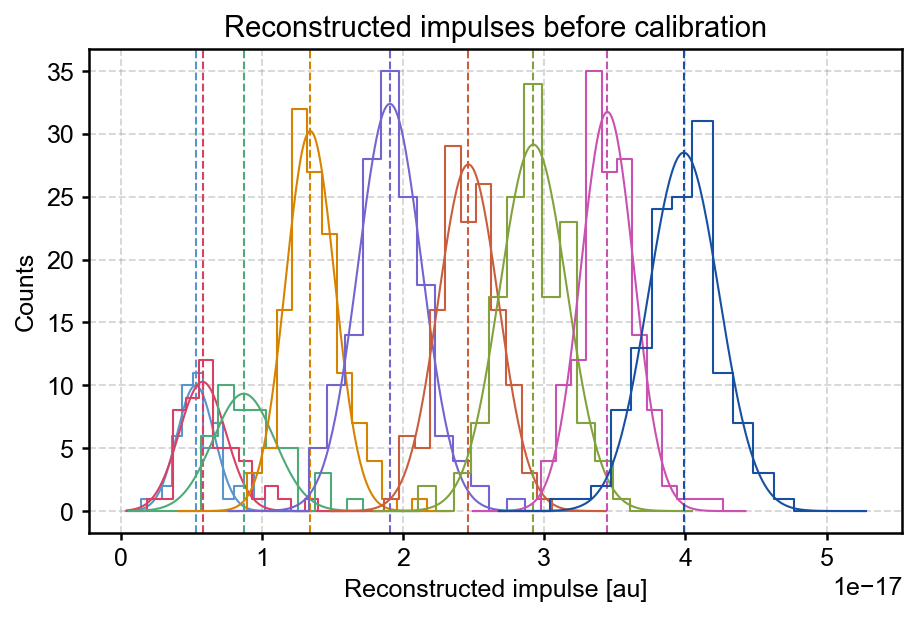

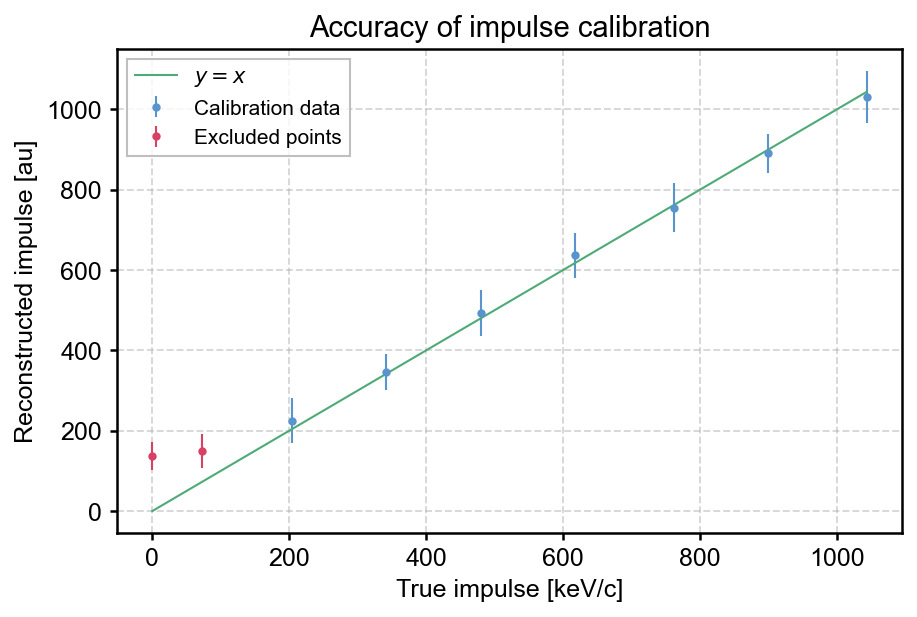

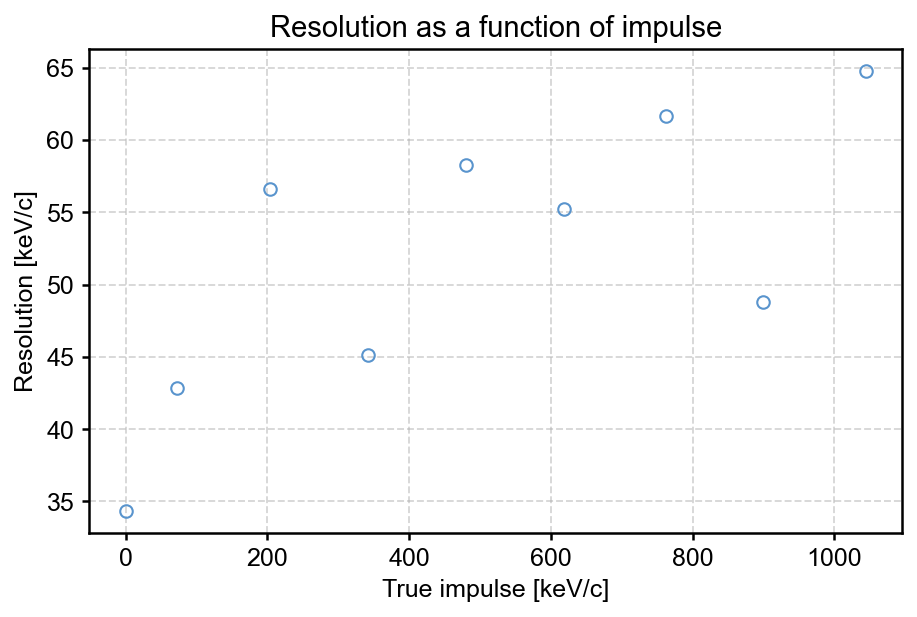

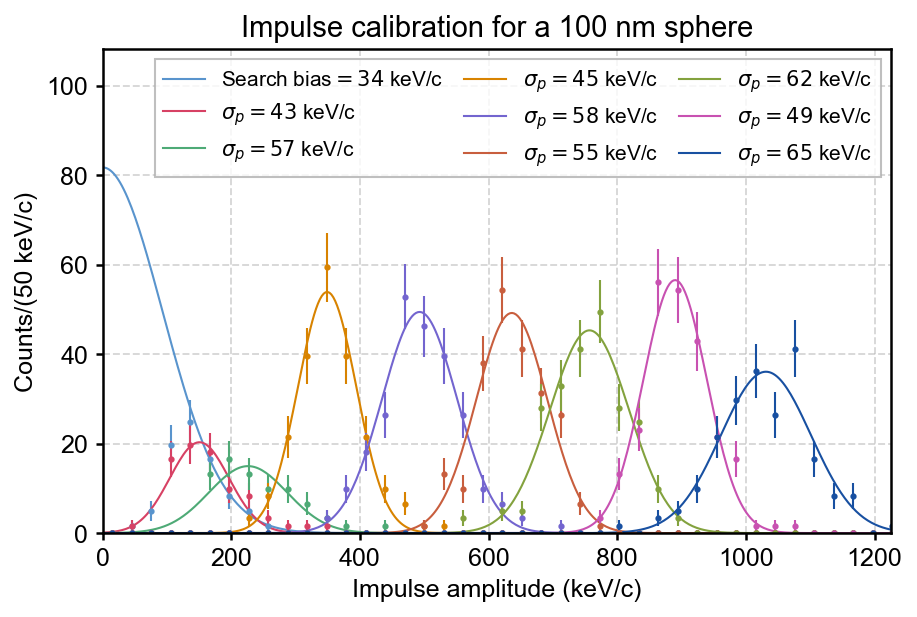

In [11]:
def gaus(x, A, mu, sigma):
    """Gaussian function.
    """
    return A*np.exp(-(x - mu)**2/2/sigma**2)

def half_gaus(x, A, sigma):
    """Half-Gaussian function.
    """
    return A*np.exp(-x**2/2/sigma**2)

def slope(x, y, sigma=1):
    """Analytic form of the best-fit slope to two
    series of data.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    sigma = np.asarray(sigma)

    w = 1.0 / sigma**2
    denom = np.sum(w * x**2)
    if denom == 0:
        raise ValueError("Degenerate x values; slope is undefined.")

    return np.sum(w * x * y) / denom

means = []
errs = []

fig, ax = plt.subplots(figsize=(6, 4), layout='constrained')
for i, imp_all in enumerate(impulses):
    imp = imp_all[mask[i]]
    mean = np.mean(np.abs(imp))
    std = np.std(np.abs(imp))
    counts, bins = np.histogram(np.abs(imp), bins=np.linspace(np.amax((0, mean - 5*std)), mean + 5*std, 20))
    bins = (bins[:-1] + bins[1:])/2.
    p, _ = curve_fit(gaus, bins, counts, p0=(10, np.mean(np.abs(imp)), np.std(np.abs(imp))))
    plot_bins = np.linspace(bins[0], bins[-1], 200)
    ax.step(bins, counts, color='C' + str(i), where='mid')
    ax.plot(plot_bins, gaus(plot_bins, *p), color='C' + str(i))
    means.append(p[1])
    errs.append(np.abs(p[2]))
    ax.axvline(p[1], ls='--', color='C' + str(i))
ax.set_xlabel('Reconstructed impulse [au]')
ax.set_ylabel('Counts')
# ax.set_xlim([0, 250])
ax.set_title('Reconstructed impulses before calibration')
ax.grid()
if plot_path:
    fig.savefig(plot_path + '_recon_uncal.pdf')

means = np.array(means)
errs = np.array(errs)

exclude_first = 2 # how many of the first datasets to exclude from the calibration line fit

# compute the scaling from Newtons to keV/c
to_keV = 1./slope(pulse_amps_keV[exclude_first:], means[exclude_first:], errs[exclude_first:])

fig, ax = plt.subplots(figsize=(6, 4), layout='constrained')
plot_amps = np.linspace(0, np.amax(pulse_amps_keV), 2)
ax.errorbar(pulse_amps_keV[exclude_first:], to_keV*means[exclude_first:], \
            to_keV*errs[exclude_first:], marker='.', ls='none', label='Calibration data')
ax.errorbar(pulse_amps_keV[:exclude_first], to_keV*means[:exclude_first], \
            to_keV*errs[:exclude_first], marker='.', ls='none', label='Excluded points')
ax.plot(plot_amps, plot_amps, label='$y=x$')
ax.set_xlabel('True impulse [keV/c]')
ax.set_ylabel('Reconstructed impulse [au]')
ax.set_title('Accuracy of impulse calibration')
ax.legend()
ax.grid()
if plot_path:
    fig.savefig(plot_path + '_calibration.pdf')

fig, ax = plt.subplots(figsize=(6, 4), layout='constrained')
ax.plot(pulse_amps_keV, to_keV*errs, marker='o', ls='none', fillstyle='none')
ax.set_xlabel('True impulse [keV/c]')
ax.set_ylabel('Resolution [keV/c]')
ax.set_title('Resolution as a function of impulse')
ax.grid()
if plot_path:
    fig.savefig(plot_path + '_resolution.pdf')

fig, ax = plt.subplots(figsize=(6, 4), layout='constrained')
for i, imp_all in enumerate(impulses):
    imp = imp_all[mask[i]]
    if i == 0:
        label = 'Search bias$={:.0f}$ keV/c'.format(errs[i]*to_keV)
    else:
        label = '$\\sigma_p = {:.0f}$ keV/c'.format(errs[i]*to_keV)
    imp_cal = np.abs(imp)*to_keV #- cal_params[1]/cal_params[0]
    counts, bins = np.histogram(imp_cal, bins=np.linspace(0, 3000, 100))
    counts = counts * 50/(bins[1] - bins[0])
    bins = (bins[:-1] + bins[1:])/2.
    p0 = (100, np.mean(imp_cal), np.std(imp_cal))
    try:
        if i == 0:
            fit_ind = np.argmax(counts)
            p, _ = curve_fit(half_gaus, bins[fit_ind + 1:], counts[fit_ind + 1:], p0=[p0[0], p0[2]])
            p = np.array([p[0], 0, p[1]])
        else:
            p, _ = curve_fit(gaus, bins, counts, p0=p0)

    except RuntimeError:
        p = p0
    plot_bins = np.linspace(0, bins[-1], 1000)
    # ax.step(bins, counts, color='C' + str(i - 1), alpha=0.5, where='mid')
    ax.errorbar(bins, counts, np.sqrt(counts), color='C' + str(i), ls='none', marker='.', ms=4)
    ax.plot(plot_bins, gaus(plot_bins, *p), color='C' + str(i), label=label)
ax.set_xlim([0, means[-1]*to_keV + 3*errs[-1]*to_keV])
ax.set_ylim([0, 3*np.amax(gaus(plot_bins, *p))])
ax.set_xlabel('Impulse amplitude (keV/c)')
ax.set_ylabel('Counts/(50 keV/c)')
ax.grid()
ax.legend(ncol=len(impulses)//3, fontsize=10, columnspacing=1)
ax.set_title('Reconstructed impulses after calibration')
ax.set_title(f'Impulse calibration for a {config['d_sphere_nm']:.0f} nm sphere')
if plot_path:
    fig.savefig(plot_path + '_recon_cal.pdf')

resolutions = errs*to_keV
for pulse, res in zip(pulse_amps_keV, resolutions):
    print('{:.0f} keV/c impulse:\t {:.1f} keV resolution'.format(pulse, res))

print('----------------------------------------------')
print('Mean resolution:\t {:.1f} keV'.format(np.mean(resolutions[exclude_first:])))

### Show calibrated waveforms

Same as a couple cells above, but now in keV/c and showing a comparison to the true impulses (dashed black lines).

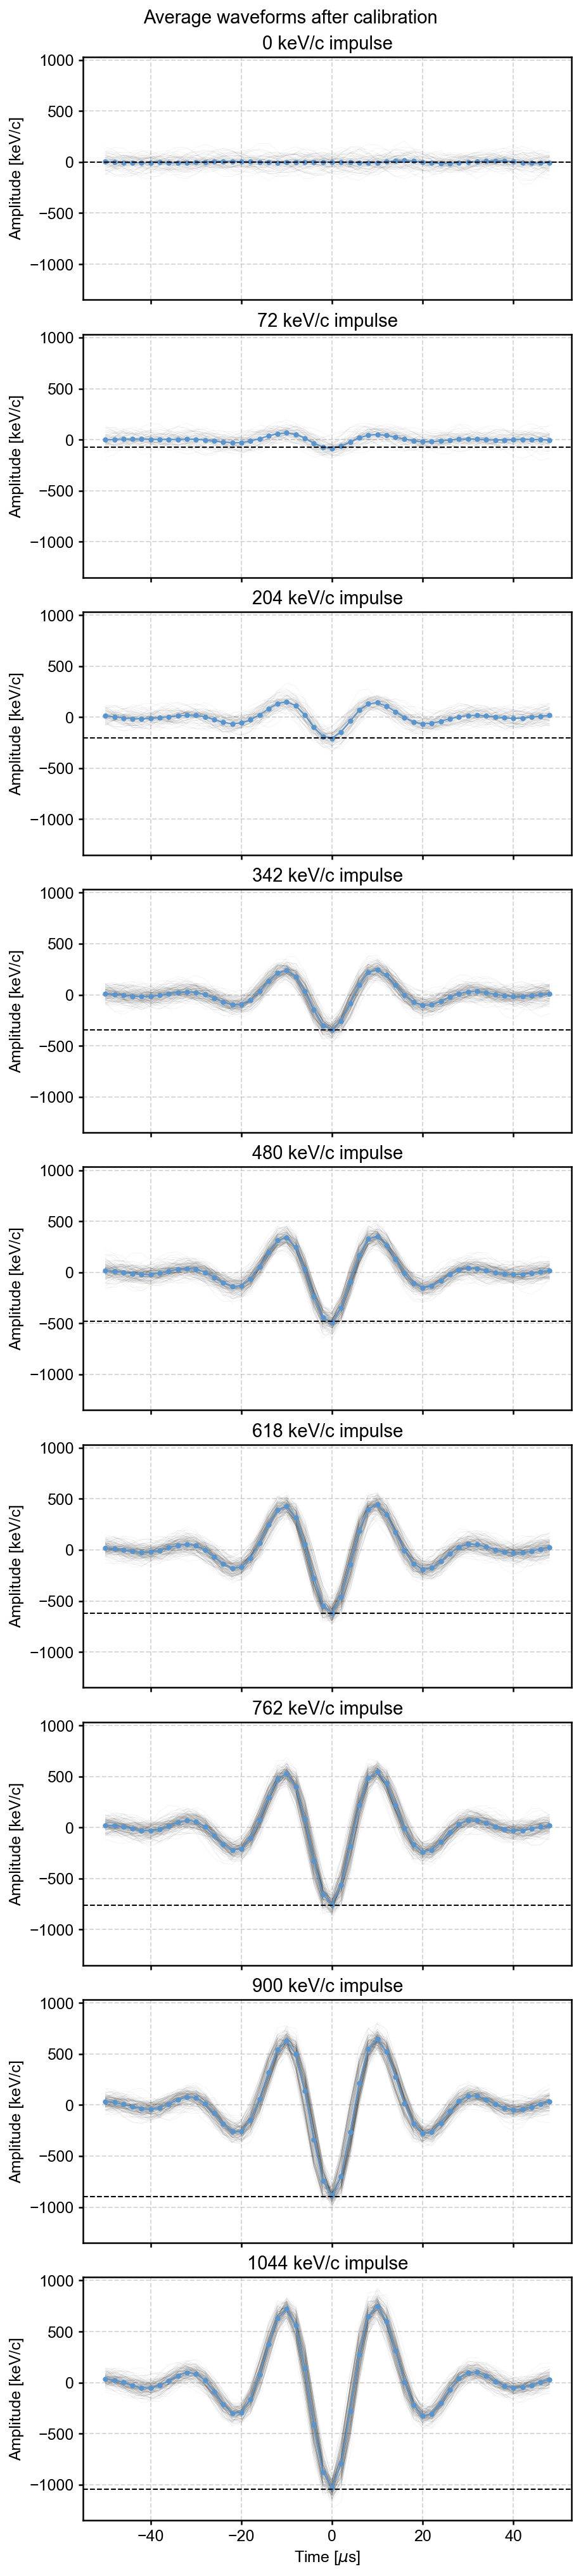

In [23]:
fig, ax = plt.subplots(mean_pulses_true_imp.shape[0], figsize=(6, 3*mean_pulses_true_imp.shape[0]), \
                       sharex=True, sharey=True, layout='constrained')
for i in range(mean_pulses_true_imp.shape[0]):
    ax[i].plot(time_slice*1e6, to_keV*pulses_true_imp[i].T, lw=0.2, alpha=0.1, color='k')
    ax[i].plot(time_slice*1e6, to_keV*mean_pulses_true_imp[i], marker='.')
    ax[i].axhline(-pulse_amps_keV[i], color='k', ls='--')
    ax[i].set_ylabel('Amplitude [keV/c]')
    ax[i].set_title('{:.0f} keV/c impulse'.format(pulse_amps_keV[i]))
    ax[i].grid(which='both')
ax[-1].set_xlabel(r'Time [$\mu$s]')
fig.suptitle('Average waveforms after calibration')
if plot_path:
    fig.savefig(plot_path + '_avg_wfms_cal.pdf')

### See how pulse shape changes with amplitude

The pulse shape should ideally remain constant with amplitude -- check that here. If the pulse shape is consistent then we use the waveform from the largest impulse data as the template since the noise will be comparatively smaller.

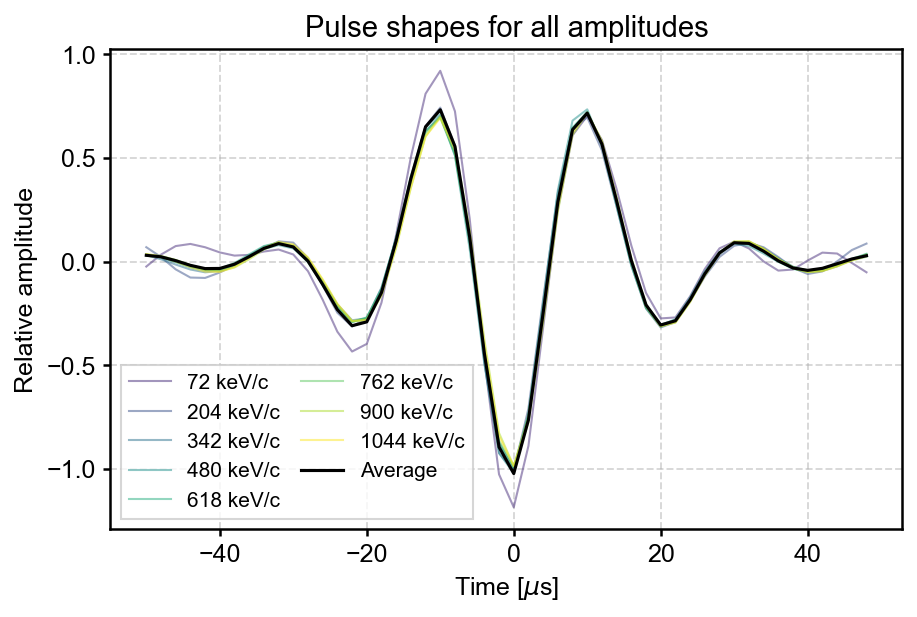

In [24]:
colors = [plt.get_cmap('viridis',len(pulse_amps_keV))(i) for i in range(len(pulse_amps_keV))]

fig, ax = plt.subplots(figsize=(6, 4), layout='constrained')
for i, mp in enumerate(mean_pulses_true_imp):
    if i == 0:
        continue
    ax.plot(time_slice*1e6, to_keV*mp/pulse_amps_keV[i], alpha=0.5, color=colors[i], label='{:.0f} keV/c'.format(pulse_amps_keV[i]))
ax.plot(time_slice*1e6, np.mean(to_keV*mean_pulses_true_imp[1:]/pulse_amps_keV[1:, None], axis=0), color='k', lw=1.5, label='Average')
ax.set_xlabel(r'Time [$\mu$s]')
ax.set_ylabel('Relative amplitude')
ax.set_title('Pulse shapes for all amplitudes')
ax.legend(ncol=len(pulse_amps_keV)//4, columnspacing=1., fontsize=10)
ax.grid(which='both')
if plot_path:
    fig.savefig(plot_path + '_wfm_shapes.pdf')

pulse_1_keV = to_keV*mean_pulses_true_imp[-1]/pulse_amps_keV[-1]
pulse_1_keV *= np.sign(pulse_1_keV[np.argmax(np.abs(pulse_1_keV))])

### Look for an amplitude dependence on goodness of fit

Compute the $\chi^2$ and ensure that it is roughly flat with impulse amplitude.

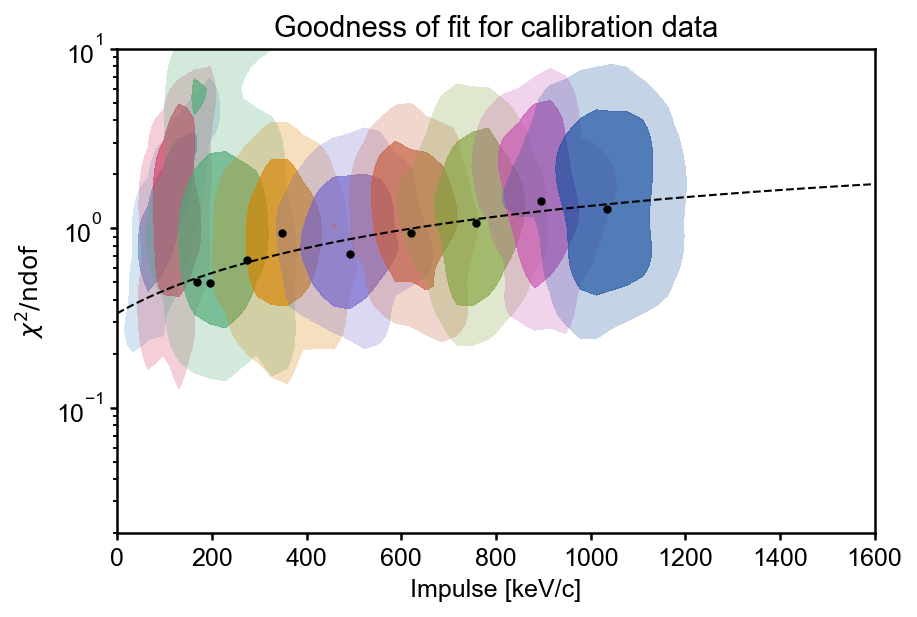

In [166]:
fig, ax = plt.subplots(figsize=(6, 4), layout='constrained')

ndof = len(pulse_1_keV) - 1
resolution = np.sqrt(np.mean(resolutions[2:]**2))

# Global grid so contours are comparable across iterations
x_min, x_max = 0, 1600
y_min, y_max = 2e-2, 1e1
nx, ny = 50, 50

xc = np.linspace(x_min, x_max, nx)
yc_log = np.linspace(np.log10(y_min), np.log10(y_max), ny)
X, YLOG = np.meshgrid(xc, yc_log)

xvals, yvals = [], []

for i, (pu, im) in enumerate(zip(pulses_true_imp, impulses)):
    chi2 = np.nansum(
        (to_keV * pu - to_keV * im[:, None] * pulse_1_keV[None, :])**2
        / resolution**2,
        axis=1,
    )

    x = to_keV * np.abs(im)
    y = chi2 / ndof

    xvals.append(np.mean(x))
    yvals.append(np.mean(y))

    # Filter invalid points (avoid -inf in log)
    m = np.isfinite(x) & np.isfinite(y) & (y > 0)
    x = x[m]
    y = y[m]
    if x.size < 20:
        continue

    logy = np.log10(y)

    # 2D KDE in (x, log10(y))
    data = np.vstack([x, logy])
    kde = stats.gaussian_kde(data, bw_method="scott")  # or e.g. 0.3 / "silverman"

    # Evaluate KDE on the grid
    grid = np.vstack([X.ravel(), YLOG.ravel()])
    Z = kde(grid).reshape(YLOG.shape)

    # Convert KDE to an approximate PDF over the grid for enclosed-probability contours
    dx = xc[1] - xc[0]
    dy = yc_log[1] - yc_log[0]
    pdf = Z * dx * dy

    pdf_flat = pdf.ravel()
    if not np.any(pdf_flat > 0):
        continue

    idx = np.argsort(pdf_flat)[::-1]
    cdf = np.cumsum(pdf_flat[idx])

    # Levels corresponding to 68% and 95% enclosed probability (HDR contours)
    levels_pdf = []
    for frac in (0.68, 0.95):
        j = min(np.searchsorted(cdf, frac), len(idx) - 1)
        levels_pdf.append(pdf_flat[idx][j])

    l1, l2 = sorted(levels_pdf)           # increasing for contour/contourf
    levels_fill = [l1, l2, pdf.max()]     # fill 2σ ring + 1σ core

    # Plot in original y (log axis)
    Y = 10**YLOG

    ax.contourf(
        X, Y, pdf,
        levels=levels_fill,
        colors=[f"C{i}", f"C{i}"],
        alpha=[0.25, 0.75],
    )

xvals = np.asarray(xvals)
yvals = np.asarray(yvals)

def quad(x, a, b, c):
    return a*x**2 + b*x + c

p, _ = curve_fit(quad, xvals, yvals)

xplot = np.linspace(x_min, x_max, 100)

ax.plot(xvals, yvals, color='k', ls='none', marker='.')
ax.plot(xplot, quad(xplot, *p), '--k')

ax.set_yscale("log")
ax.set_xlim([x_min, x_max])
ax.set_ylim([y_min, y_max])
ax.set_xlabel("Impulse [keV/c]")
ax.set_ylabel(r"$\chi^2 / \mathrm{ndof}$")
ax.set_title('Goodness of fit for calibration data')
if plot_path:
    fig.savefig(plot_path + '_chi2_vs_imp.pdf')

### Add the calibration parameters to the config file

Everything computed in this notebook that is relevant for future analysis can then be added to the config file and automatically used when processing future impulse search data.

In [13]:
config['keV_per_N'] = float(to_keV)
config['template'] = [float(i) for i in pulse_1_keV]
config['resolution'] = float(resolution)
config['meters_per_volt'] = float(meters_per_volt)

config_path = 'configs/' + base_path.split('pulse_calibration/')[-1] + dataset
os.makedirs(config_path, exist_ok=True)

with open(config_path + '/config.yaml', 'w') as f:
    yaml.safe_dump(config, f)